In [530]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [531]:
df = pd.read_csv('ispu_dki_all.csv')
df.head()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [532]:
df.shape

(5538, 11)

In [533]:
# Rename the columns
df.rename(columns={'tanggal': 'date', 'stasiun': 'station', 'categori': 'category'}, inplace=True)
df.head()

,date,station,pm25,pm10,so2,co,o3,no2,max,critical,category
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [534]:
# category is the target, check category's unique values
uniqueVal = df['category'].unique()
print(uniqueVal)

['SEDANG' 'BAIK' 'TIDAK SEHAT' 'TIDAK ADA DATA' 'SANGAT TIDAK SEHAT'
 'BERBAHAYA']


In [535]:
# rename the values to English
df['category'] = df['category'].replace({'SEDANG':'MODERATE', 'BAIK': 'GOOD', 'TIDAK SEHAT': 'UNHEALTHY', 'TIDAK ADA DATA': 'NO DATA', 'SANGAT TIDAK SEHAT': 'VERY UNHEALTHY', 'BERBAHAYA': 'DANGER'})
df.head()

,date,station,pm25,pm10,so2,co,o3,no2,max,critical,category
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,MODERATE
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,GOOD
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,GOOD
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,GOOD
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,GOOD


In [536]:
df['category'].unique()

array(['MODERATE', 'GOOD', 'UNHEALTHY', 'NO DATA', 'VERY UNHEALTHY',
       'DANGER'], dtype=object)

In [537]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      5538 non-null   object 
 1   station   5537 non-null   object 
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   object 
 10  category  5538 non-null   object 
dtypes: float64(7), object(4)
memory usage: 476.1+ KB


In [538]:
# change data type
df['date'] = pd.to_datetime(df['date'])

In [539]:
# check missing values
df.isna().sum()

date           0
station        1
pm25        4022
pm10         315
so2          130
co            88
o3           104
no2          106
max            1
critical       4
category       0
dtype: int64

In [540]:
missing_percentages= df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
print(missing_percentages)


pm25        72.63
pm10         5.69
so2          2.35
no2          1.91
o3           1.88
co           1.59
critical     0.07
max          0.02
station      0.02
date         0.00
category     0.00
dtype: float64


In [541]:
# check duplicated rows
df.duplicated().sum()

np.int64(0)

1. there aren't any duplicated rows.
2. column pm25 has to many missing values, eventhough it might be very a critical feature, it's better to drop the column.
3. fill in missing values with > 1% missing data with median, because pollution data usually has spikes.
4. remove missing values with < 1% missing data


In [542]:
# drop column pm25
df = df.drop(columns=['pm25'])

In [543]:
cols = ['pm10','so2','no2','o3','co']
for c in cols:
    df[c] = df[c].fillna(df[c].median())

In [544]:
df = df.dropna(subset=['critical','max','station'])

In [545]:
df.isna().sum()

date        0
station     0
pm10        0
so2         0
co          0
o3          0
no2         0
max         0
critical    0
category    0
dtype: int64

In [546]:
# drop unnecassary columns
df = df.drop(columns=['station', 'date'])

In [547]:
df.head()

,pm10,so2,co,o3,no2,max,critical,category
0,60.0,4.0,73.0,27.0,14.0,73.0,CO,MODERATE
1,32.0,2.0,16.0,33.0,9.0,33.0,O3,GOOD
2,27.0,2.0,19.0,20.0,9.0,27.0,PM10,GOOD
3,22.0,2.0,16.0,15.0,6.0,22.0,PM10,GOOD
4,25.0,2.0,17.0,15.0,8.0,25.0,PM10,GOOD


In [548]:
df['critical'].value_counts()

critical
O3      2970
PM25    1408
PM10     944
SO2      103
CO        83
NO2       25
Name: count, dtype: int64

since we dropped 'pm25' column, we need to erase PM25 value in critical column, but PM25 has the second highest amount of value in the 'critical' column, therefore we need to change it with other available values.

In [549]:
pm25_val = df[df['critical']== 'PM25']
pm25_val

,pm10,so2,co,o3,no2,max,critical,category
3896,69.0,25.0,8.0,70.0,13.0,96.0,PM25,MODERATE
3899,56.0,25.0,16.0,54.0,6.0,88.0,PM25,MODERATE
3903,64.0,25.0,6.0,59.0,11.0,90.0,PM25,MODERATE
3904,54.0,28.0,11.0,62.0,9.0,97.0,PM25,MODERATE
3909,72.0,26.0,7.0,89.0,11.0,102.0,PM25,UNHEALTHY
...,...,...,...,...,...,...,...,...
5533,45.0,52.0,18.0,19.0,40.0,70.0,PM25,MODERATE
5534,18.0,28.0,13.0,25.0,4.0,75.0,PM25,MODERATE
5535,46.0,57.0,11.0,11.0,51.0,65.0,PM25,MODERATE
5536,29.0,24.0,21.0,34.0,8.0,111.0,PM25,UNHEALTHY


In [550]:
pollutant_cols = ['pm10', 'so2', 'co', 'o3', 'no2']

In [551]:
# replace old max value with current max value
df['max'] = df[pollutant_cols].max(axis=1)

In [552]:
# replace PM25 value in 'critical' column with other values
df['critical'] = df[pollutant_cols].idxmax(axis=1)
df['critical'] = df['critical'].str.upper() #make all values uppercase

In [553]:
df['category'].value_counts()

category
MODERATE          3186
UNHEALTHY         1827
GOOD               316
VERY UNHEALTHY     203
DANGER               1
Name: count, dtype: int64

'max' values changed, therefore the 'category' column values are also affected based on the 'max' values.

In [554]:
def categorize(max_val):
    if max_val <= 50:
        return 'GOOD'
    elif max_val > 50 and max_val <= 100:
        return 'MODERATE'
    elif max_val > 100 and max_val <=200:
        return 'UNHEALTHY'
    elif max_val > 200 and max_val <=300:
        return 'VERY UNHEALTHY'
    else:
        return 'DANGER'

df['category'] = df['max'].apply(categorize)

In [555]:
df['category'].value_counts()

category
MODERATE          3525
UNHEALTHY         1328
GOOD               483
VERY UNHEALTHY     196
DANGER               1
Name: count, dtype: int64

In 'category' column, DANGER only has 1 value which is really low. Therefore, it's modified to VERY UNHEALTHY value.

In [556]:
df['category'] = df['category'].replace('DANGER', 'VERY UNHEALTHY')
df['category'].value_counts()

category
MODERATE          3525
UNHEALTHY         1328
GOOD               483
VERY UNHEALTHY     197
Name: count, dtype: int64

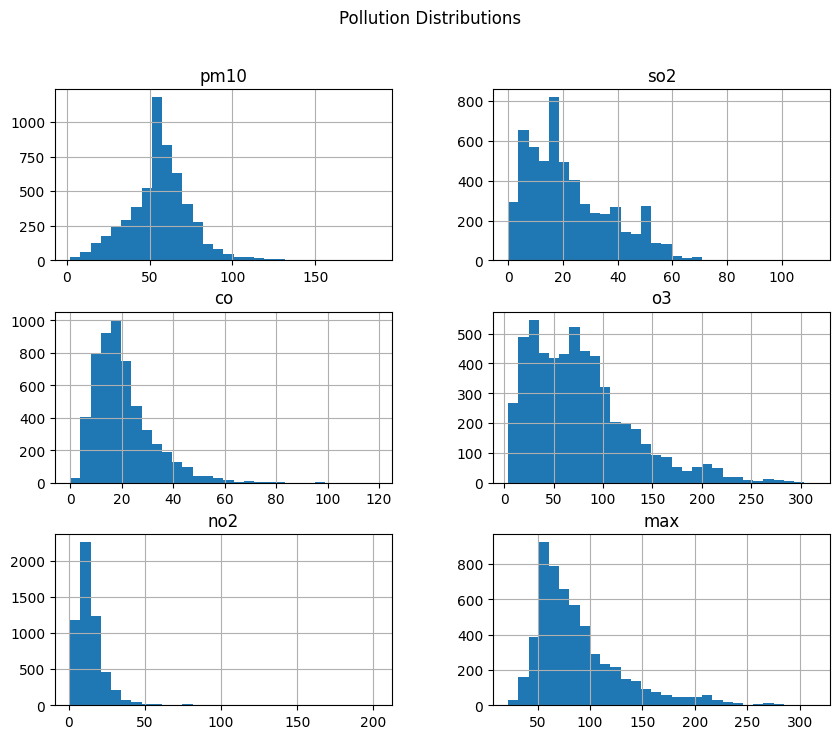

In [557]:
cols = ['pm10', 'so2', 'co', 'o3', 'no2', 'max']

df[cols].hist(figsize=(10,8), bins=30)
plt.suptitle("Pollution Distributions")
plt.show()

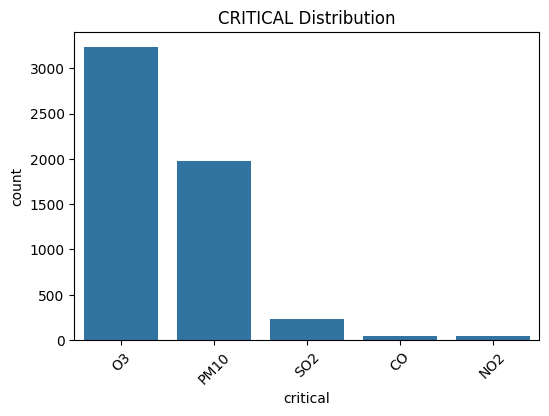

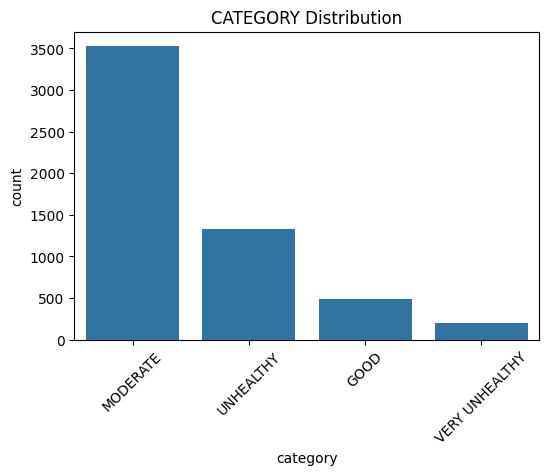

In [558]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col.upper()} Distribution")
    plt.xticks(rotation=45)
    plt.show()

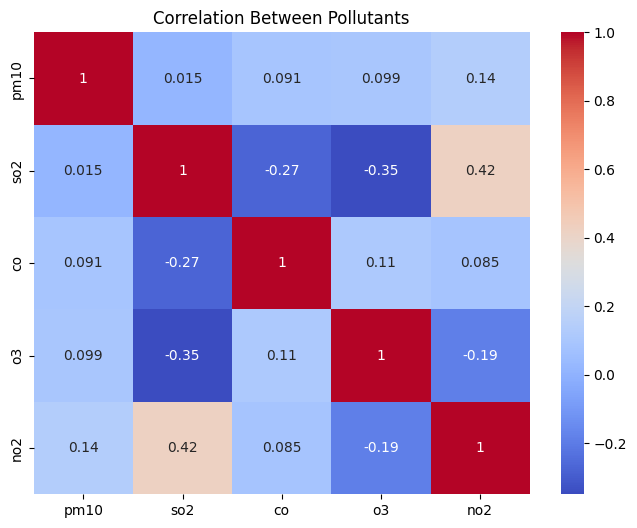

In [559]:
plt.figure(figsize=(8,6))
sns.heatmap(df[pollutant_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Pollutants")
plt.show()

In [560]:
df[pollutant_cols].describe()

,pm10,so2,co,o3,no2
count,5533.000000,5533.000000,5533.000000,5533.000000,5533.000000
mean,56.439183,22.331285,20.381710,77.316103,14.300560
std,19.442477,15.286584,11.875589,51.344322,9.955933
min,2.000000,0.000000,0.000000,4.000000,1.000000
25%,46.000000,11.000000,12.000000,36.000000,8.000000
50%,57.000000,18.000000,18.000000,69.000000,12.000000
75%,66.000000,31.000000,25.000000,102.000000,18.000000
max,187.000000,112.000000,119.000000,314.000000,202.000000


In [561]:
df.to_csv('cleanedData.csv')